In [1]:
# import pickle

# with open("data3.pkl", "rb") as f:
#     bmat = pickle.load(f)


In [1]:
import os
os.environ["NUMBA_DISABLE_JIT"] = "1"

In [2]:
from pp_solvers.equation_variable_groups import *

interface_groups = [
    InterfaceDarcyFluxGroup(),
    InterfaceEnthalpyFluxGroup(),
    InterfaceFourierFluxGroup(),
    WellFluxGroup(),
    WellEnthalpyFluxGroup(),
]
print(interface_groups)

mass_balance_groups = [MassBalancePressureGroup(), ProductionPressureConstraintGroup()]
energy_balance_groups = [
    EnergyBalanceEnthalpyGroup(),
    InjectionTemperatureConstraintGroup(),
]
component_groups = [ComponentMassBalanceCO2Group()]

print(mass_balance_groups + energy_balance_groups + component_groups)

NameError: name 'AbstractGroup' is not defined

In [ ]:
from abc import ABC, abstractmethod

from pp_solvers.dof_manager import DofManager


def append_prefix_to_options(prefix: str, options: dict):
    return {f"{prefix}{key}": value for key, value in options.items()}


class PetscKspPcConfiguration(ABC):
    def __init__(self, groups: list[EquationVariableGroup], key: str) -> None:
        # keys - for the access of user options, must be unique
        # should have semantic meaning, like "mechanics_subsolver"
        self.groups: list[EquationVariableGroup] = groups
        self.key: str = key

    def __repr__(self) -> str:
        return f"{self.__class__.__name__}(groups={self.groups})"

    @abstractmethod
    def petsc_options(self, user_options: dict, prefix: str) -> dict:
        pass

    def petsc_assembly_config(
        self, user_options: dict, prefix: str, dof_manager: DofManager
    ) -> dict:
        return {}


class ILU(PetscKspPcConfiguration):
    def __init__(self, groups: list[EquationVariableGroup], key: str = "ilu") -> None:
        super().__init__(groups=groups, key=key)

    def petsc_options(self, user_options: dict, prefix: str) -> dict:
        default_options = {"pc_type": "ilu"}
        return append_prefix_to_options(
            prefix=prefix, options=default_options | user_options.get(self.key, {})
        )


class AMG(PetscKspPcConfiguration):
    def __init__(self, groups: list[EquationVariableGroup], key: str = "amg") -> None:
        super().__init__(groups=groups, key=key)

    def petsc_options(self, user_options: dict, prefix: str) -> dict:
        # This is where the default can be model-dependent. E.g. if 2d, strong_th=0.3
        # and 0.7 if 3d.
        default_options = {"pc_type": "hypre", "pc_hypre_type": "boomeramg"}
        return append_prefix_to_options(
            prefix=prefix, options=default_options | user_options.get(self.key, {})
        )


class Identity(PetscKspPcConfiguration):
    def __init__(
        self, groups: list[EquationVariableGroup], key: str = "identity"
    ) -> None:
        super().__init__(groups=groups, key=key)

    def petsc_options(self, user_options: dict, prefix: str) -> dict:
        default_options = {"pc_type": "none"}
        return append_prefix_to_options(
            prefix=prefix, options=default_options | user_options.get(self.key, {})
        )


class GMRES(PetscKspPcConfiguration):
    def __init__(
        self, preconditioner: PetscKspPcConfiguration, key: str = "gmres"
    ) -> None:
        self.preconditioner: PetscKspPcConfiguration = preconditioner
        super().__init__(groups=self.preconditioner.groups, key=key)

    def __repr__(self) -> str:
        return f"GMRES(preconditioner={self.preconditioner})"

    def petsc_options(self, user_options: dict, prefix: str) -> dict:
        default_options = {
            "ksp_type": "gmres",
            "ksp_pc_side": "right",
            "ksp_rtol": 1e-12,
            "ksp_max_it": 300,
            "ksp_gmres_restart": 100,
            "ksp_gmres_cgs_refinement_type": "refine_ifneeded",
            "ksp_gmres_classicalgramschmidt": True,  # Not givens rotations??
        }
        pc_options = self.preconditioner.petsc_options(
            user_options=user_options, prefix=prefix
        )
        return append_prefix_to_options(
            prefix=prefix,
            options=pc_options | default_options | user_options.get(self.key, {}),
        )

    def petsc_assembly_config(
        self, user_options: dict, prefix: str, dof_manager: DofManager
    ) -> dict:
        return self.preconditioner.petsc_assembly_config(
            user_options=user_options, prefix=prefix, dof_manager=dof_manager
        )


class DiagonalInvertor:
    def default_petsc_options(self, user_options: dict, prefix: str) -> dict:
        return {}

    def petsc_assembly_config(
        self, user_options: dict, prefix: str, dof_manager: DofManager
    ) -> dict:
        return {}


class CompositePreconditioner(PetscKspPcConfiguration):
    def __init__(
        self, subsolvers: list[PetscKspPcConfiguration], key: str = "composite"
    ) -> None:
        assert len(subsolvers) >= 1
        groups_of_subsolvers = [subsolver.groups for subsolver in subsolvers]
        for groups in groups_of_subsolvers[1:]:
            assert groups == groups_of_subsolvers[0]
        super().__init__(groups_of_subsolvers[0], key=key)
        self.subsolvers: list[PetscKspPcConfiguration] = subsolvers

    def __repr__(self) -> str:
        return f"CompositePreconditioner(subsolvers={self.subsolvers})"

    def petsc_options(self, user_options: dict, prefix: str) -> dict:
        result: dict = {
            "pc_type": "composite",
            "pc_composite_type": "multiplicative",
        }
        for i, subsolver in enumerate(self.subsolvers):
            result |= subsolver.petsc_options(
                user_options=user_options, prefix=f"sub_{i}_"
            )
        return append_prefix_to_options(
            prefix=prefix, options=result | user_options.get(self.key, {})
        )

    def petsc_assembly_config(
        self, user_options: dict, prefix: str, dof_manager: DofManager
    ) -> dict:
        config = {
            prefix: {
                "pc_type": "composite",
                "num_stages": len(self.subsolvers),
            },
        }
        for i, subsolver in enumerate(self.subsolvers):
            subsolver_prefix = f"{prefix}sub_{i}_"
            config |= subsolver.petsc_assembly_config(
                user_options=user_options,
                prefix=subsolver_prefix,
                dof_manager=dof_manager,
            )
        return config


from pp_solvers.dof_manager import DofManager


class FieldSplit(PetscKspPcConfiguration):
    def __init__(
        self,
        subsolver: PetscKspPcConfiguration,
        complement: PetscKspPcConfiguration,
        approximate_invertor: DiagonalInvertor,
        petsc_tag: str = "elim",
        petsc_complement_tag: str = "keep",
        key: str = "fieldsplit",
    ) -> None:
        # petsc_tag - internal, for petsc prefix. Must be short, not necessarily unique.
        self.subsolver: PetscKspPcConfiguration = subsolver
        self.complement: PetscKspPcConfiguration = complement
        self.approximate_invertor: DiagonalInvertor = approximate_invertor
        self.petsc_tag: str = petsc_tag
        self.petsc_complement_tag: str = petsc_complement_tag
        super().__init__(groups=self.subsolver.groups + self.complement.groups, key=key)

        # assert set(self.subsolver.groups).intersection(self.complement.groups) == 0

    def __repr__(self) -> str:
        return (
            f"FieldSplit(subsolver={self.subsolver}, complement={self.complement}, "
            f"approximate_invertor={self.approximate_invertor})"
        )

    def petsc_options(self, user_options: dict, prefix: str) -> dict:
        options = (
            {
                "pc_type": "fieldsplit",
                "pc_fieldsplit_type": "schur",
                "pc_fieldsplit_schur_factorization_type": "upper",
                "pc_fieldsplit_schur_precondition": "selfp",  # should be determined by the invertor
                # default values for the children.
                f"fieldsplit_{self.petsc_tag}_ksp_type": "preonly",
                f"fieldsplit_{self.petsc_complement_tag}_ksp_type": "preonly",
            }
            | self.subsolver.petsc_options(
                user_options=user_options, prefix=f"fieldsplit_{self.petsc_tag}_"
            )
            | self.complement.petsc_options(
                user_options=user_options,
                prefix=f"fieldsplit_{self.petsc_complement_tag}_",
            )
            | self.approximate_invertor.default_petsc_options(
                user_options=user_options, prefix="fieldsplit_"
            )
        )
        return append_prefix_to_options(
            prefix=prefix, options=options | user_options.get(self.key, {})
        )

    def petsc_assembly_config(
        self, user_options: dict, prefix: str, dof_manager: DofManager
    ) -> dict:
        return (
            {
                prefix: {
                    "pc_type": "fieldsplit",
                    "elim_tag": self.petsc_tag,
                    "keep_tag": self.petsc_complement_tag,
                    "elim_groups": dof_manager.indices_of_groups(
                        groups=self.subsolver.groups
                    ),
                    "keep_groups": dof_manager.indices_of_groups(
                        groups=self.complement.groups
                    ),
                }
            }
            | self.subsolver.petsc_assembly_config(
                user_options=user_options,
                prefix=f"{prefix}fieldsplit_{self.petsc_tag}_",
                dof_manager=dof_manager,
            )
            | self.complement.petsc_assembly_config(
                user_options=user_options,
                prefix=f"{prefix}fieldsplit_{self.petsc_complement_tag}_",
                dof_manager=dof_manager,
            )
            | self.approximate_invertor.petsc_assembly_config(
                user_options=user_options,
                prefix=f"{prefix}fieldsplit_",
                dof_manager=dof_manager,
            )
        )


from pp_solvers.preconditioners import _to_cell_ordering, PcPythonPermutation


class PythonWrapper(PetscKspPcConfiguration):
    def __init__(
        self,
        python_context: PcPythonPermutation,
        inner_subsolver: PetscKspPcConfiguration,
        key: str = "python_wrapper",
    ) -> None:
        super().__init__(groups=inner_subsolver.groups, key=key)
        self.python_context: PcPythonPermutation = python_context
        self.inner_subsolver: PetscKspPcConfiguration = inner_subsolver

    def petsc_options(self, user_options: dict, prefix: str) -> dict:
        options = {"pc_type": "python"} | self.inner_subsolver.petsc_options(
            user_options=user_options, prefix=f"python_"
        )
        return append_prefix_to_options(
            prefix=prefix, options=options | user_options.get(self.key, {})
        )
        # what if user options change pc_type? We assume it is prohibited. Somewhere it
        # should be checked.

    def petsc_assembly_config(
        self, user_options: dict, prefix: str, dof_manager: DofManager
    ) -> dict:
        return {
            prefix: {
                "pc_type": "python",
                "python_context": self.python_context,
            }
        }


def nested_schur_complements(subsolvers: list[dict]) -> FieldSplit:
    if len(subsolvers) != 2:
        # recursion
        return FieldSplit(
            subsolver=subsolvers[0]["subsolver"],
            approximate_invertor=subsolvers[0]["approximate_invertor"],
            complement=nested_schur_complements(subsolvers=subsolvers[1:]),
        )
    # end of recursion
    return FieldSplit(
        subsolver=subsolvers[0]["subsolver"],
        approximate_invertor=subsolvers[0]["approximate_invertor"],
        complement=subsolvers[1]["subsolver"],
    )


interface_preconditioner = {
    "subsolver": ILU(groups=interface_groups, key="interface_prec"),
    "approximate_invertor": DiagonalInvertor(),
}

cpr = {
    "subsolver": CompositePreconditioner(
        subsolvers=[
            FieldSplit(
                subsolver=Identity(
                    groups=energy_balance_groups + component_groups,
                    key="cpr_stage0_identity",
                ),
                approximate_invertor=DiagonalInvertor(),
                complement=AMG(groups=mass_balance_groups, key="cpr_stage0_amg"),
                key="inner_fieldsplit",
            ),
            # PythonWrapper(
            #     python_context=PcPythonPermutation(
            #         perm=_to_cell_ordering(
            #             bmat.indexer, group_lists=[[5], [6], [7]]
            #         ),  # issue with groups here
            #         block_size=3,
            #     ),
            #     inner_subsolver=ILU(
            #     groups=energy_balance_groups + component_groups + mass_balance_groups,
            #     key="cpr_stage1_ilu",
            # ),
            # ),
            ILU(
                groups=energy_balance_groups + component_groups + mass_balance_groups,
                key="cpr_stage1_ilu",
            ),
        ]
    )
}

linear_solver = GMRES(
    preconditioner=nested_schur_complements(
        [
            interface_preconditioner,
            cpr,
        ]
    )
)
linear_solver

GMRES(preconditioner=FieldSplit(subsolver=ILU(groups=[InterfaceDarcyFluxGroup, InterfaceEnthalpyFluxGroup, InterfaceFourierFluxGroup, WellFluxGroup, WellEnthalpyFluxGroup]), complement=CompositePreconditioner(subsolvers=[FieldSplit(subsolver=Identity(groups=[EnergyBalanceEnthalpyGroup, InjectionTemperatureConstraintGroup, ComponentMassBalanceCO2Group]), complement=AMG(groups=[MassBalancePressureGroup, ProductionPressureConstraintGroup]), approximate_invertor=<__main__.DiagonalInvertor object at 0x7ed10361c7d0>), ILU(groups=[EnergyBalanceEnthalpyGroup, InjectionTemperatureConstraintGroup, ComponentMassBalanceCO2Group, MassBalancePressureGroup, ProductionPressureConstraintGroup])]), approximate_invertor=<__main__.DiagonalInvertor object at 0x7ed102cc1400>))

In [ ]:
[
    interface_preconditioner,
    cpr,
]

In [5]:
from porepy.examples.cold_co2_injection.run import make_model

model, *_ = make_model(pc_factory=lambda: linear_solver)
model.before_nonlinear_loop()
model.before_nonlinear_iteration()


--- start of run script ---

Equilibrium condition: unified-p-h
Refinement level: 0
Local tolerance case: 2
Local iteration stride: 3
Number of months: 20
Relative permeability: linear
Time schedule: False



INFO:porepy.compositional.peng_robinson.eos:(import peng_robinson/eos.py) Compiling Peng-Robinson EoS from symbolic source ..
DEBUG:porepy.compositional.peng_robinson.eos:(import peng_robinson/eos.py) Compiling cubic polynomial ..
DEBUG:porepy.compositional.peng_robinson.eos:(import peng_robinson/eos.py) Compiling A-B space functions ..
DEBUG:porepy.compositional.peng_robinson.eos:(import peng_robinson/eos.py) Compiling compressibility factors ..
DEBUG:porepy.compositional.peng_robinson.eos:(import peng_robinson/eos.py) Compiling general compressibility factor ..
INFO:porepy.compositional.peng_robinson.eos:(import peng_robinson/eos.py) Done (elapsed time: 0.00464 (s)).
INFO:porepy.compositional.peng_robinson.eos:Compiling symbolic Peng-Robinson EoS ..
DEBUG:porepy.compositional.peng_robinson.eos:Compiling symbolic functions 1/12
DEBUG:porepy.compositional.peng_robinson.eos:Compiling symbolic functions 2/12
DEBUG:porepy.compositional.peng_robinson.eos:Compiling symbolic functions 3/12
D

DEBUG:porepy.compositional.compiled_flash.uniflash:Initial values computed (elapsed time: 0.35077 (s)).
INFO:porepy.compositional.compiled_flash.uniflash:308 p-T flash solved (elapsed time: 1.58270 (s)).
DEBUG:porepy.compositional.compiled_flash.uniflash:Success: 308 / 308; Max iter: 0; Diverged: 0; Failures: 0; Iterations: 1 (max) 1 (avg);
INFO:porepy.models.compositional_flow_with_equilibrium:Initial equilibration on grid 1.
DEBUG:porepy.compositional.compiled_flash.uniflash:1 p-T flash target state(s) parsed; Problem size: 5; Solver: npipm (parallel);
DEBUG:porepy.compositional.compiled_flash.uniflash:Initial values computed (elapsed time: 0.00116 (s)).
INFO:porepy.compositional.compiled_flash.uniflash:1 p-T flash solved (elapsed time: 0.00064 (s)).
DEBUG:porepy.compositional.compiled_flash.uniflash:Success: 1 / 1; Max iter: 0; Diverged: 0; Failures: 0; Iterations: 0 (max) 0 (avg);
INFO:porepy.models.compositional_flow_with_equilibrium:Initial equilibration on grid 3.
DEBUG:porepy.c

In [6]:
model.assemble_linear_system()

In [7]:
from pp_solvers.block_linear_system import BlockLinearSystem

bmat: BlockLinearSystem = model.bmat
dof_manager: DofManager = model._solver_components.dof_manager

In [8]:
user_options = {
    "gmres": {
        'ksp_monitor': None,
        'ksp_type': 'fgmres',
    },
    "cpr_stage1_ilu": {
        "pc_type": "hypre",
        "pc_hypre_type": "ilu",
        "pc_hypre_ilu_level": 2,
        "pc_hypre_ilu_maxiter": 10,
    },
    'interface_prec': {
        'pc_type': 'ilu'
    }
}

linear_solver.petsc_options(user_options=user_options, prefix="")

{'pc_type': 'fieldsplit',
 'pc_fieldsplit_type': 'schur',
 'pc_fieldsplit_schur_factorization_type': 'upper',
 'pc_fieldsplit_schur_precondition': 'selfp',
 'fieldsplit_elim_ksp_type': 'preonly',
 'fieldsplit_keep_ksp_type': 'preonly',
 'fieldsplit_elim_pc_type': 'ilu',
 'fieldsplit_keep_pc_type': 'composite',
 'fieldsplit_keep_pc_composite_type': 'multiplicative',
 'fieldsplit_keep_sub_0_pc_type': 'fieldsplit',
 'fieldsplit_keep_sub_0_pc_fieldsplit_type': 'schur',
 'fieldsplit_keep_sub_0_pc_fieldsplit_schur_factorization_type': 'upper',
 'fieldsplit_keep_sub_0_pc_fieldsplit_schur_precondition': 'selfp',
 'fieldsplit_keep_sub_0_fieldsplit_elim_ksp_type': 'preonly',
 'fieldsplit_keep_sub_0_fieldsplit_keep_ksp_type': 'preonly',
 'fieldsplit_keep_sub_0_fieldsplit_elim_pc_type': 'none',
 'fieldsplit_keep_sub_0_fieldsplit_keep_pc_type': 'hypre',
 'fieldsplit_keep_sub_0_fieldsplit_keep_pc_hypre_type': 'boomeramg',
 'fieldsplit_keep_sub_1_pc_type': 'hypre',
 'fieldsplit_keep_sub_1_pc_hypre_ty

In [9]:
linear_solver.petsc_assembly_config(
    user_options=user_options, prefix="", dof_manager=dof_manager
)

{'': {'pc_type': 'fieldsplit',
  'elim_tag': 'elim',
  'keep_tag': 'keep',
  'elim_groups': [0, 1, 2, 3, 4],
  'keep_groups': [5, 6, 7, 8, 9]},
 'fieldsplit_keep_': {'pc_type': 'composite', 'num_stages': 2},
 'fieldsplit_keep_sub_0_': {'pc_type': 'fieldsplit',
  'elim_tag': 'elim',
  'keep_tag': 'keep',
  'elim_groups': [5, 6, 7],
  'keep_groups': [8, 9]}}

In [ ]:
from pp_solvers.options_parsers import assemble_petsc_ksp_pc
from pp_solvers.petsc_utils import (
    csr_to_petsc,
    clear_petsc_options,
    insert_petsc_options,
)

import petsc4py

petsc4py.init()

from petsc4py import PETSc

ksp = PETSc.KSP().create()
petsc_mat = csr_to_petsc(bmat.mat)
ksp.setOperators(petsc_mat, petsc_mat)
clear_petsc_options()
insert_petsc_options(
    linear_solver.petsc_options(
        user_options=user_options,
        prefix="",
    )
)

assemble_petsc_ksp_pc(
    ksp=ksp,
    pc=ksp.getPC(),
    assembly_config=linear_solver.petsc_assembly_config(
        user_options=user_options, prefix="", dof_manager=dof_manager
    ),
    indexer=bmat.indexer,
)


In [14]:
rhs_petsc = petsc_mat.getVecLeft()
sol_petsc = petsc_mat.getVecRight()
rhs_petsc.setArray(bmat.rhs)

ksp.solve(rhs_petsc, sol_petsc)

  0 KSP Residual norm 2.605209646267e+03
  1 KSP Residual norm 2.605173332878e+03
  2 KSP Residual norm 2.567851563965e+03
  3 KSP Residual norm 2.268870298982e+01
  4 KSP Residual norm 1.720789350113e-03
  5 KSP Residual norm 4.958381314419e-07
  6 KSP Residual norm 1.233523150366e-10


In [60]:
from pp_solvers.mat_utils import _inv_direct
from pp_solvers.petsc_utils import (
    csr_to_petsc,
    petsc_to_csr,
    clear_petsc_options,
    insert_petsc_options,
    construct_is,
)
from pp_solvers.preconditioners import _to_cell_ordering, PcPythonPermutation

import petsc4py

petsc4py.init()

from petsc4py import PETSc


ksp = PETSc.KSP().create()
petsc_mat = csr_to_petsc(bmat.mat)
ksp.setOperators(petsc_mat, petsc_mat)
clear_petsc_options()
options = {
    # ksp
    "ksp_type": "fgmres",
    "ksp_pc_side": "right",
    "ksp_rtol": 1e-12,
    "ksp_max_it": 120,
    "ksp_gmres_cgs_refinement_type": "refine_ifneeded",
    "ksp_gmres_classicalgramschmidt": True,  # Not givens rotations??
    "ksp_monitor": None,
    # pc
    "pc_type": "fieldsplit",
    "pc_fieldsplit_type": "schur",
    "pc_fieldsplit_schur_factorization_type": "upper",
    "pc_fieldsplit_schur_precondition": "selfp",
    # elim (interfaces)
    "fieldsplit_elim_ksp_type": "preonly",
    # 'fieldsplit_elim_ksp_monitor': None,
    "fieldsplit_elim_pc_type": "ilu",
    # keep PCComposite (P-T-Z)
    "fieldsplit_keep_ksp_type": "preonly",
    # 'fieldsplit_keep_ksp_monitor': None,
    "fieldsplit_keep_pc_type": "composite",
    "fieldsplit_keep_pc_composite_type": "multiplicative",
    # sub_0 PCFieldSplit (P-T-Z)
    "fieldsplit_keep_sub_0_pc_type": "fieldsplit",
    "fieldsplit_keep_sub_0_pc_fieldsplit_type": "schur",
    "fieldsplit_keep_sub_0_pc_fieldsplit_schur_factorization_type": "upper",
    "fieldsplit_keep_sub_0_pc_fieldsplit_schur_precondition": "selfp",
    # elim (Z)
    "fieldsplit_keep_sub_0_fieldsplit_elim_ksp_type": "preonly",
    # 'fieldsplit_keep_sub_0_fieldsplit_elim_ksp_monitor': None,
    "fieldsplit_keep_sub_0_fieldsplit_elim_pc_type": "none",
    # 'fieldsplit_keep_sub_0_fieldsplit_elim_pc_hypre_type': 'ilu',
    # keep (P-T)
    "fieldsplit_keep_sub_0_fieldsplit_keep_ksp_type": "preonly",
    # "fieldsplit_keep_sub_0_fieldsplit_keep_ksp_rtol": 1e-10,
    # 'fieldsplit_keep_sub_0_fieldsplit_keep_ksp_monitor': None,
    # "fieldsplit_keep_sub_0_fieldsplit_keep_pc_type": "none",
    "fieldsplit_keep_sub_0_fieldsplit_keep_pc_type": "hypre",
    "fieldsplit_keep_sub_0_fieldsplit_keep_pc_hypre_type": "boomeramg",
    # sub_1 (P-T-Z)
    "fieldsplit_keep_sub_1_pc_type": "python",
    "fieldsplit_keep_sub_1_python_pc_type": "hypre",
    "fieldsplit_keep_sub_1_python_pc_hypre_type": "ilu",
    # "fieldsplit_keep_sub_1_python_pc_hypre_ilu_logging": 3,
    # "fieldsplit_keep_sub_1_python_pc_hypre_ilu_print_level": 3,
    "fieldsplit_keep_sub_1_python_pc_hypre_ilu_level": 2,
    "fieldsplit_keep_sub_1_python_pc_hypre_ilu_maxiter": 10,
}
insert_petsc_options(options)


In [61]:
a = set(linear_solver.petsc_options(user_options=user_options, prefix="").items())
b = set(options.items())
print(a.difference(b))
print(b.difference(a))

{('ksp_gmres_restart', 100), ('ksp_max_it', 300)}
{('ksp_max_it', 120)}


In [ ]:
prefix = 'fieldsplit_keep_'
a = set(linear_solver.petsc_assembly_config(user_options=user_options, prefix="")[prefix].items())
b = set(additional_data[prefix].items())
print(a.difference(b))
print(b.difference(a))

TypeError: unhashable type: 'list'

In [71]:
additional_data

{'': {'pc_type': 'fieldsplit',
  'elim_tag': 'elim',
  'keep_tag': 'keep',
  'elim_groups': [0, 1, 2, 3, 4],
  'keep_groups': [5, 6, 7]},
 'fieldsplit_keep_': {'pc_type': 'composite', 'num_stages': 2},
 'fieldsplit_keep_sub_0_': {'pc_type': 'fieldsplit',
  'elim_tag': 'elim',
  'keep_tag': 'keep',
  'elim_groups': [6, 7],
  'keep_groups': [5]},
 'fieldsplit_keep_sub_1_': {'pc_type': 'python',
  'python_context': <pp_solvers.petsc_solvers.PcPythonPermutation at 0x7bc533ad6fd0>}}

In [74]:
prefix = 'fieldsplit_keep_sub_0_'

linear_solver.petsc_assembly_config(user_options=user_options, prefix="")[prefix]

{'pc_type': 'fieldsplit',
 'elim_tag': 'elim',
 'keep_tag': 'keep',
 'elim_groups': [5, 6],
 'keep_groups': [7]}

In [75]:
additional_data[prefix]

{'pc_type': 'fieldsplit',
 'elim_tag': 'elim',
 'keep_tag': 'keep',
 'elim_groups': [6, 7],
 'keep_groups': [5]}

- intf: no difference
- composite: hard to converge with GMRES
- z with GMRES-ILU: inner - hard, outer converges in 8 iteratiosn
- p with GMRES-AMG: inner - easy, outer - hard to converge
-


In [ ]:
from pp_solvers.block_linear_system import LinearSystemIndexer
from pp_solvers.options_parsers import assemble_petsc_ksp_pc
from warnings import warn

additional_data = {
    "": {
        "pc_type": "fieldsplit",
        "elim_tag": "elim",
        "keep_tag": "keep",
        "elim_groups": [0, 1, 2, 3, 4],
        "keep_groups": [5, 6, 7],
    },
    "fieldsplit_keep_": {
        "pc_type": "composite",
        "num_stages": 2,
    },
    "fieldsplit_keep_sub_0_": {
        "pc_type": "fieldsplit",
        "elim_tag": "elim",
        "keep_tag": "keep",
        "elim_groups": [6, 7],
        "keep_groups": [5],
    },
    "fieldsplit_keep_sub_1_": {
        "pc_type": "python",
        "python_context": PcPythonPermutation(
            perm=_to_cell_ordering(bmat.indexer, group_lists=[[5], [6], [7]]),
            block_size=3,
        ),
    },
}

assemble_petsc_ksp_pc(
    ksp=ksp, pc=ksp.getPC(), assembly_config=additional_data, indexer=bmat.indexer
)

In [33]:
rhs_petsc = petsc_mat.getVecLeft()
sol_petsc = petsc_mat.getVecRight()
rhs_petsc.setArray(bmat.rhs)

ksp.solve(rhs_petsc, sol_petsc)

  0 KSP Residual norm 6.812268192221e+03
  1 KSP Residual norm 6.812226004216e+03
  2 KSP Residual norm 6.389161076336e+03
  3 KSP Residual norm 1.127974901068e+02
  4 KSP Residual norm 7.623912438648e+00
  5 KSP Residual norm 2.498755271580e-01
  6 KSP Residual norm 7.556262504037e-03
  7 KSP Residual norm 6.185263954611e-04
  8 KSP Residual norm 2.579175108159e-05
  9 KSP Residual norm 1.109776447274e-06
 10 KSP Residual norm 2.240030043582e-08
 11 KSP Residual norm 5.118478846663e-10


In [9]:
ksp.reason

-9

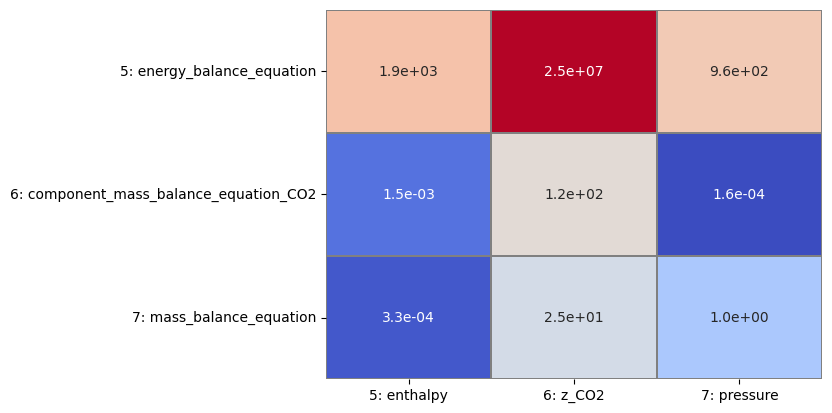

In [ ]:
bmat[[5, 6, 7]].plot_max()